In [14]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import math
import trimesh
import torch.nn.functional as F
from sklearn.metrics import mean_squared_error, mean_absolute_error

np.random.seed(42)
torch.manual_seed(42)

In [15]:
def histogram_generator(data, title, xlabel, bins):
    data_flatten = data.flatten()
    
    # Compute the histogram
    hist, bin_edges = np.histogram(data_flatten, bins=bins)
    
    # Plot the histogram using bar
    plt.figure(figsize=(10, 6))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    plt.bar(bin_centers, hist, width=np.diff(bin_edges), align='center')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

In [143]:
### convert lidar frame from gloabl ref to relative reference

def gloabl_lidar_to_relative(dataset):
    lidar = np.empty((0, 300))
    for i in range(dataset.shape[0]):
        for j in range(dataset.shape[1]):
            position = [dataset[i, j, 7], dataset[i, j, 8], dataset[i, j, 9]]*100
            position = np.array(position).reshape(100, 3)
            
            lidar_data = dataset[i, j, 10:]
            lidar_data = lidar_data.reshape(100, 3)

            # convert to relative frame
            lidar_data = lidar_data - position

            # convert inf to 0
            # for k in range(len(lidar_data)):
            #     if (math.isinf(lidar_data[k][0])):
            #         lidar_data[k][0] = 0
            #         lidar_data[k][1] = 0
            #         lidar_data[k][2] = 0
            lidar = np.concatenate((lidar, lidar_data.reshape(1, 300)), axis=0)
    
    lidar = np.array(lidar, dtype=np.float32)
    lidar = np.nan_to_num(lidar, 0)
    return lidar

In [105]:
## Converting lidar to range data

def normalize_range(x, minx=0, maxx=10):
    return (x - minx) / (maxx - minx)

def distance(x, y):
    dist = (x[0]-y[0])**2 + (x[1]-y[1])**2 + (x[2]-y[2])**2
    if math.isinf(dist):
       return 10
        
    return math.sqrt(dist)

def getRange(position, lidar):
    range_data = []
    for i in range(len(lidar)):
        dist = normalize_range(distance(position, lidar[i]))
        range_data.append(dist)
        
    return np.array(range_data)

def generator_lidar_range(dataset):
    lidar_range = np.empty((0, 100))
    for i in range(dataset.shape[0]):
        for j in range(dataset.shape[1]):
            position = [dataset[i, j, 7], dataset[i, j, 8], dataset[i, j, 9]]
            range_data = getRange(position, dataset[i, j, 10:].reshape(100, 3)).reshape(1, -1)
            lidar_range = np.concatenate((lidar_range, range_data), axis=0)
    
    lidar_range = lidar_range.reshape(data.shape[0], data.shape[1], -1)
    return lidar_range

In [46]:
def dataset_loader(dataset):
    train_size = int(0.7 * len(dataset))
    test_size = len(dataset) - train_size
    train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
    
    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=100, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=200, shuffle=False)

    return train_loader, test_loader

In [176]:
class FCN(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_sizes
        self.output_size = output_size
        
        self.steps = nn.Sequential(
            nn.Linear(input_size, hidden_sizes[0]),
            nn.ReLU(), # Activation layer
            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(), # Activation layer
            nn.Linear(hidden_sizes[1], output_size)
        )

    def forward(self, x):
        x = self.steps(x)
        return x


# input for input, hidden, output ex: input_size = 100, hidden_sizes=[100, 100], output_size=100
def FCNTrain(num_epochs, train, input_size, hidden_sizes, output_size):
    model = FCN(input_size = input_size, hidden_sizes=hidden_sizes, output_size=output_size)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    
    for epoch in range(num_epochs):
        model.train()
        for input_seq in train:
            input_seq = input_seq[:, :input_size]
            input_seq = torch.nan_to_num(input_seq, nan=1e-6, posinf=1e-6, neginf=1e-6)
    
            output = model(input_seq)
            target_val = input_seq
    
            loss = criterion(output, target_val)  # shape: [batch, 100]
    
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    return model

In [138]:
## Autoencoder, compression
# https://www.geeksforgeeks.org/auto-encoders/

class AutoEncoder(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super(AutoEncoder, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_sizes
        self.output_size = output_size
        
        self.encoder = nn.Sequential(
            nn.Linear(input_size, hidden_sizes[0]),
            nn.ReLU(), # Activation layer
            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(), # Activation layer
            nn.Linear(hidden_sizes[1], output_size)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(output_size, hidden_sizes[1]),
            nn.ReLU(), # Activation layer
            nn.Linear(hidden_sizes[1], hidden_sizes[0]),
            nn.ReLU(), # Activation layer
            nn.Linear(hidden_sizes[0], input_size),
        )
    
    def forward(self, input_data):
        encoded = self.encoder(input_data)
        decoded = self.decoder(encoded)
        return encoded, decoded

# ex for sizes: input_size = 100, hidden_sizes=[50, 25], output_size=5
def AETrain(num_epochs, train, input_size, hidden_sizes, output_size):
    model = AutoEncoder(input_size = input_size, hidden_sizes=hidden_sizes, output_size=output_size)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    
    for epoch in range(num_epochs):
        model.train()
            
        for input_seq in train:
            input_seq = input_seq[:, :input_size]
            input_seq = torch.nan_to_num(input_seq, nan=1e-6, posinf=1e-6, neginf=1e-6)
    
            encoded, decoded = model(input_seq)
            target_val = input_seq
    
            loss = criterion(decoded, target_val)  # shape: [batch, 100]
    
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    return model      

In [49]:
### Test on actual model
# -----------------------------------------------------------------------------------------------------------------------------------------

In [50]:
num_epochs = 100

data = np.load("data_lunar_mesh_ex.npy", allow_pickle=True)
data = data.astype(np.float32)
print(f"Loaded data shape: {data.shape}")

total_traj = data.shape[0]
seq_len = data.shape[1] + 1


data = torch.tensor(data[:,:, :10].reshape(total_traj * (seq_len - 1), 10), dtype=torch.float32)
combined_data = data.reshape(total_traj, seq_len - 1, 10)
print(combined_data.shape)

# print(data.shape)
# lidar_data = model_lidar_range(torch.tensor(lidar_range, dtype=torch.float32))
# # lidar_data, decoded = model_lidar_range_encoder(torch.tensor(lidar_range, dtype=torch.float32))
# lidar_data, decoded = model_lidar_encoder(torch.tensor(lidar.reshape(total_traj, seq_len - 1, 300)))

# test models
# combined_data = torch.cat((combined_data, lidar_data.detach().reshape(total_traj, (seq_len - 1), -1)), axis=2)
# unchanged lidar data
# combined_data = torch.cat((combined_data, torch.tensor(lidar.reshape(total_traj, seq_len - 1, 300))), axis=2)
# without above line, OG model W/O lidar
combined_data.shape

Loaded data shape: (895, 19, 310)
torch.Size([895, 19, 10])


torch.Size([895, 19, 10])

In [161]:
class TrajectoryDataset(torch.utils.data.Dataset):
    def __init__(self, data_tensor, predictions):
        self.data = data_tensor
        self.predictions = predictions

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        seq = self.data[idx]                 # shape (21, 10)
        # print(seq.shape[0])
        # print(seq.shape[0] - self.predictions)
        input_seq = seq[:seq.shape[0] - self.predictions]                 # shape (18, 10)
        target_values = seq[seq.shape[0] - self.predictions:]          # shape (3,) — 3 future values of feature[0]
        return input_seq, target_values

class LSTMMultiStep(nn.Module):
    def __init__(self, input_size=128, hidden_size=64, num_layers=1, num_pred=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_pred)  # Predict 3 future values (1 feature)
        self.activation = nn.Sigmoid()

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        last_hidden = hn[-1]                 # shape: (batch, hidden_size)
        output = self.fc(last_hidden)        # shape: (batch, 3)
        output = self.activation(output)
        return output

# returns both a trained model, and the test dataset
def MainModelTrain(data_loader, num_pred, num_epochs, input_size):  
    model = LSTMMultiStep(input_size=input_size, num_pred=num_pred)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(num_epochs):
        model.train()
        for input_seq, target_val in data_loader:
            input_seq = torch.concatenate((input_seq[:, :, :7], input_seq[:, :, 10:]), axis=2)
            output = model(input_seq)
            loss = criterion(output, target_val[:,:,0]) # Add PINNs stuff here
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    return model

(895, 19, 310)


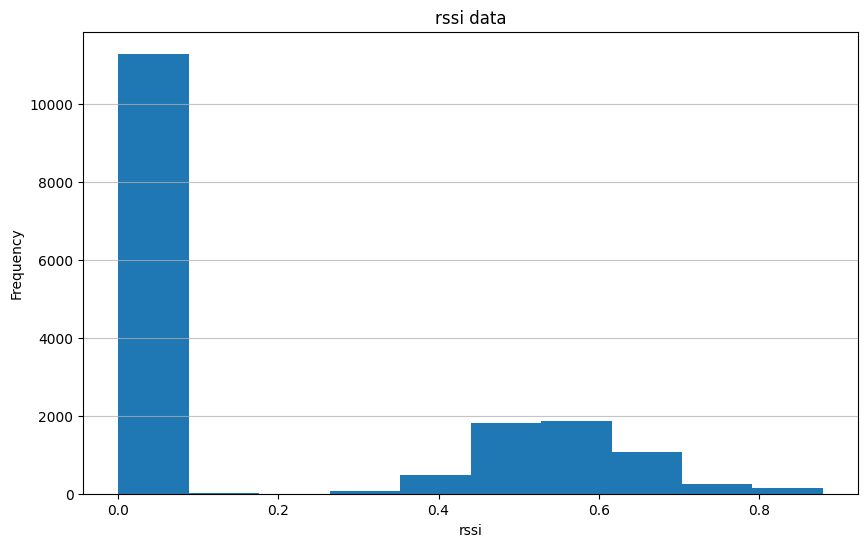

In [142]:
dataset = np.load("data_lunar_mesh_ex.npy", allow_pickle=True).astype(np.float32)
print(dataset.shape)
total_traj = dataset.shape[0]
seq_len = dataset.shape[1] + 1

# get lidar point cloud data
lidar_pc = gloabl_lidar_to_relative(dataset)

# get lidar_range data
lidar_range = generator_lidar_range(dataset)

# get main data
data = torch.tensor(dataset[:,:, :10], dtype=torch.float32)

# histogram_generator(dataset[:, :, 0], "rssi data", "rssi", 10)
# histogram_generator(lidar_range, "lidar data", "lidar", 10)
# histogram_generator(lidar_pc, "lidar data", "lidar", 10)
#mse = mean_squared_error(rssi_ground_truth[0], rssi_predicted[0])

In [155]:
def get_model_mse(combined_data, size):

    num_pred = 10
    # train_data, test_data = dataset_loader(dataset)
    dataset = TrajectoryDataset(combined_data, num_pred)
    
    # Split
    train_size = int(0.7 * len(dataset))
    test_size = len(dataset) - train_size
    train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
    
    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=200, shuffle=False)
    
    main_model = MainModelTrain(train_loader, num_pred, 100, size)

    criterion = nn.MSELoss()
    rssi_ground_truth = []
    rssi_predicted = []
    
    for input_seq, target_val in test_loader:
        input_seq = torch.concatenate((input_seq[:, :, :7], input_seq[:, :, 10:]), axis=2)
        test_output = main_model(input_seq)
        rssi_ground_truth.append(target_val[:,:,0].numpy())
        rssi_predicted.append(test_output.detach().numpy())
    
    mse = []
    for i in range(len(rssi_ground_truth)):
        mse.append(mean_squared_error(rssi_ground_truth[i], rssi_predicted[i]))
     
    return (sum(mse)/len(mse))

In [179]:
lidar_range = np.array(lidar_range, dtype=np.float32)
lidar_pc = np.array(lidar_pc, dtype=np.float32)

num_epochs = 1000
models = {"og":[], "lidar_range":[], "lidar_range_embedding":[], "lidar_fc":[], "lidar_pc_embedding":[]}

for i in range(10):
    print(i)
    # OG MODEL
    combined_data = data
    models["og"].append(get_model_mse(combined_data, combined_data.shape[2] - 3))

    # LIDAR RANGE FCN
    combined_data = data
    train_loader, test_loader = dataset_loader(lidar_range)
    fcn_range = FCNTrain(num_epochs, train_loader, 100, [100, 100], 100)
    lidar_range_fcn = fcn_range((torch.tensor(lidar_range, dtype=torch.float32)))
    combined_data = torch.cat((combined_data, lidar_range_fcn.detach().reshape(total_traj, (seq_len - 1), -1)), axis=2)
    models["lidar_range"].append(get_model_mse(combined_data, combined_data.shape[2] - 3))
 
    # LIDAR RANGE EMBEDDING
    combined_data = data
    embed_range = AETrain(num_epochs, train_loader, 100, [50, 25], 5)
    encoded_range, decoded_range = embed_range(torch.tensor(lidar_range, dtype=torch.float32))
    combined_data = torch.cat((combined_data, encoded_range.detach().reshape(total_traj, (seq_len - 1), -1)), axis=2)
    models["lidar_range_embedding"].append(get_model_mse(combined_data, combined_data.shape[2] - 3))

    # LIDAR PC FCN

    combined_data = data
    train_loader, test_loader = dataset_loader(lidar_pc)
    fcn_pc = FCNTrain(num_epochs, train_loader, 300, [300, 300], 300)
    lidar_pc_fcn = fcn_pc((torch.tensor(lidar_pc, dtype=torch.float32)))
    combined_data = torch.cat((combined_data, lidar_pc_fcn.detach().reshape(total_traj, (seq_len - 1), -1)), axis=2)
    models["lidar_fc"].append(get_model_mse(combined_data, combined_data.shape[2] - 3))

    # LIDAR PC EMBEDDING
    combined_data = data
    train_loader, test_loader = dataset_loader(lidar_pc)
    embed_pc = AETrain(num_epochs, train_loader, 300, [100, 50], 25)
    encoded_pc, decoded_pc = embed_pc(torch.tensor(lidar_pc, dtype=torch.float32))
    combined_data = torch.cat((combined_data, encoded_pc.detach().reshape(total_traj, (seq_len - 1), -1)), axis=2)
    models["lidar_pc_embedding"].append(get_model_mse(combined_data, combined_data.shape[2] - 3))

print(models["og"])
print(models["lidar_range"])
print(models["lidar_range_embedding"])
print(models["lidar_fc"])
print(models["lidar_pc_embedding"])

0
1
2
3
4
5
6
7
8
9
[0.010912188328802586, 0.01675370056182146, 0.014719957951456308, 0.014988839160650969, 0.0151942134834826, 0.014476706273853779, 0.010956695768982172, 0.013272632379084826, 0.013082554331049323, 0.012189536355435848]
[0.015557954087853432, 0.019015822559595108, 0.018224273808300495, 0.01512996293604374, 0.01172035513445735, 0.011212546844035387, 0.019792326726019382, 0.017675851937383413, 0.01742395106703043, 0.013663121731951833]
[0.014610042795538902, 0.022274097427725792, 0.017583953216671944, 0.017895353958010674, 0.01405156310647726, 0.013299725484102964, 0.01648733438923955, 0.017503690905869007, 0.012927412055432796, 0.018364036455750465]
[0.045472223311662674, 0.05608856678009033, 0.061041662469506264, 0.05631754361093044, 0.061657220125198364, 0.05528508313000202, 0.05956135876476765, 0.0535404346883297, 0.05777824856340885, 0.0618536788970232]
[0.031791853718459606, 0.03064369037747383, 0.026695593260228634, 0.03144729044288397, 0.037657467648386955, 0.03

{'whiskers': [<matplotlib.lines.Line2D at 0x12aa24b1d80>,
 'caps': [<matplotlib.lines.Line2D at 0x12aa24b22c0>,
 'boxes': [<matplotlib.lines.Line2D at 0x12aa24b1ae0>,
 'medians': [<matplotlib.lines.Line2D at 0x12aa24b2800>,
 'fliers': [<matplotlib.lines.Line2D at 0x12aa24b2aa0>,
 'means': []}

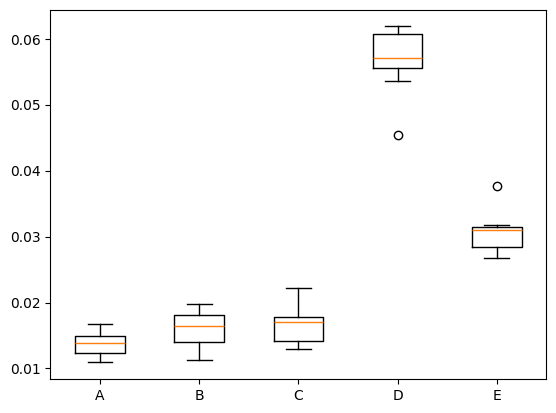

In [184]:
boxplot = {}
labels = "ABCDE"
for i in range(len(labels)):
    boxplot[labels[i]] = models[list(models.keys())[i]]
plt.boxplot(boxplot.values(), tick_labels=boxplot.keys())